In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("\n==============================")
print("STEP 9: Loading prepared dataset")
print("==============================")

# load dataset again
df = pd.read_csv("../VLCQoSData.csv", sep=";")

print("\nDataset loaded successfully")

print("\nDataset shape:")
print(df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nPreview:")
display(df.head())


STEP 9: Loading prepared dataset

Dataset loaded successfully

Dataset shape:
(300, 30)

Columns:
['id', 'QoS_bandwidth', 'QoS_packet-loss', 'QoS_delay', 'QoS_jitter', 'V_id-video', 'V_content', 'V_norm-bitrate', 'V_complexity', 'V_complexity-class', 'QoA_resolution', 'QoA-bitrate', 'QoA-frame_rate', 'QoA_frame-drop', 'QoA_audio-rate', 'QoA_audio-drop', 'QoD-cpu_mhz-moy', 'QoD-cpu_mhz-avg', 'QoD_cpu-nbr', 'QoD-cpu_core-nbr', 'QoD_stepping', 'QoD-cpu_bigo-mips', 'QoD_carte-class', 'QoD_screen-resolotion', 'QoD_screen-dimension', 'QoD_screen-mhz', 'QoD-screen_blug-type', 'QoD-ram_clock-speed', 'QoD_ram-size', 'MOS']

Preview:


,id,QoS_bandwidth,QoS_packet-loss,QoS_delay,QoS_jitter,V_id-video,V_content,V_norm-bitrate,V_complexity,V_complexity-class,...,QoD_stepping,QoD-cpu_bigo-mips,QoD_carte-class,QoD_screen-resolotion,QoD_screen-dimension,QoD_screen-mhz,QoD-screen_blug-type,QoD-ram_clock-speed,QoD_ram-size,MOS
0,1,1024,0%,0.360,0.043,3,Movie,6.422284,5.874106,0,...,7,4988.58,Radeon HD 7610M,1366 x 768,361x203,76.5,LVDS,1333,4096,1
1,2,1024,0%,0.435,0.071,3,Movie,6.422284,5.874106,0,...,9,6784.45,Radeon HD 7470,1920 x 1200,508x317,154.0,DVI-0,1600,4096,1
2,16,1024,0%,0.403,0.033,3,Movie,6.422284,5.874106,0,...,7,4988.58,Radeon HD 7610M,1366 x 768,361x203,76.5,LVDS,1333,4096,1
3,18,1024,0%,0.499,0.018,3,Movie,6.422284,5.874106,0,...,7,4988.76,Radeon HD 7610M,1366 x 768,361x203,76.5,LVDS,1333,4096,1
4,19,1024,0%,0.472,0.034,3,Movie,6.422284,5.874106,0,...,7,4988.76,Radeon HD 7610M,1366 x 768,361x203,76.5,LVDS,1333,4096,1


In [2]:
print("\n==============================")
print("STEP 10: Cleaning packet loss column")
print("==============================")

print("\nUnique values BEFORE cleaning:")
print(df["QoS_packet-loss"].unique())

df["QoS_packet-loss"] = df["QoS_packet-loss"].str.replace("%","")
df["QoS_packet-loss"] = df["QoS_packet-loss"].astype(float)

print("\nUnique values AFTER cleaning:")
print(df["QoS_packet-loss"].unique())

print("\nColumn type:")
print(df["QoS_packet-loss"].dtype)


STEP 10: Cleaning packet loss column

Unique values BEFORE cleaning:
['0%']

Unique values AFTER cleaning:
[0.]

Column type:
float64



STEP 11: MOS Distribution
MOS
1    38
2    56
3    77
4    65
5    64
Name: count, dtype: int64


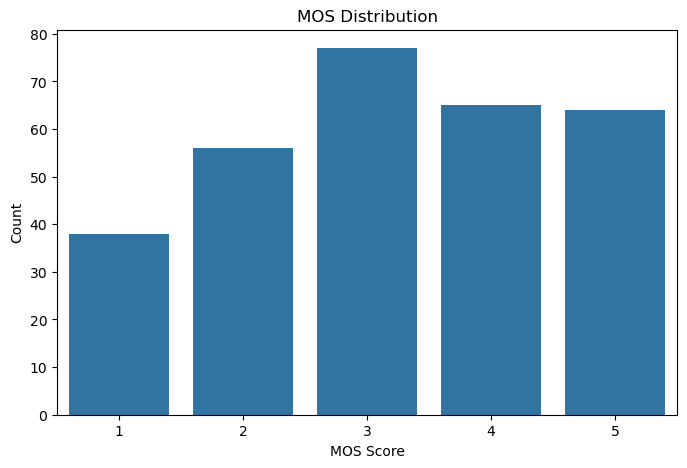

In [3]:
print("\n==============================")
print("STEP 11: MOS Distribution")
print("==============================")

print(df["MOS"].value_counts().sort_index())

plt.figure(figsize=(8,5))

sns.countplot(x=df["MOS"])

plt.title("MOS Distribution")
plt.xlabel("MOS Score")
plt.ylabel("Count")

plt.show()

In [4]:
print("\n==============================")
print("STEP 12: Feature Groups")
print("==============================")

qos_features = [
    "QoS_bandwidth",
    "QoS_packet-loss",
    "QoS_delay",
    "QoS_jitter"
]

video_features = [
    "V_norm-bitrate",
    "V_complexity",
    "V_complexity-class"
]

qoa_features = [
    "QoA_resolution",
    "QoA-bitrate",
    "QoA-frame_rate",
    "QoA_frame-drop",
    "QoA_audio-rate",
    "QoA_audio-drop"
]

qod_features = [
    "QoD-cpu_mhz-moy",
    "QoD-cpu_mhz-avg",
    "QoD_cpu-nbr",
    "QoD-cpu_core-nbr",
    "QoD-cpu_bigo-mips",
    "QoD_ram-size"
]

print("QoS features:", qos_features)
print("Video features:", video_features)
print("QoA features:", qoa_features)
print("QoD features:", qod_features)


STEP 12: Feature Groups
QoS features: ['QoS_bandwidth', 'QoS_packet-loss', 'QoS_delay', 'QoS_jitter']
Video features: ['V_norm-bitrate', 'V_complexity', 'V_complexity-class']
QoA features: ['QoA_resolution', 'QoA-bitrate', 'QoA-frame_rate', 'QoA_frame-drop', 'QoA_audio-rate', 'QoA_audio-drop']
QoD features: ['QoD-cpu_mhz-moy', 'QoD-cpu_mhz-avg', 'QoD_cpu-nbr', 'QoD-cpu_core-nbr', 'QoD-cpu_bigo-mips', 'QoD_ram-size']



STEP 13: Correlation with MOS

Correlation with MOS:
MOS                    1.000000
id                     0.890642
QoS_bandwidth          0.839049
QoA_audio-rate         0.778254
QoA_resolution         0.744820
QoA-frame_rate         0.719889
QoA-bitrate            0.719186
QoA_audio-drop         0.113710
QoA_frame-drop         0.086584
QoD-cpu_mhz-moy        0.073617
QoD-cpu_core-nbr       0.024442
QoD_cpu-nbr            0.023991
QoD-cpu_bigo-mips      0.023942
QoD_screen-mhz         0.023459
QoD-ram_clock-speed    0.022285
QoD_stepping           0.022283
QoD_ram-size           0.019065
V_id-video             0.008914
V_norm-bitrate        -0.010734
V_complexity-class    -0.013723
QoS_jitter            -0.017901
V_complexity          -0.022329
QoD-cpu_mhz-avg       -0.033368
QoS_delay             -0.095784
QoS_packet-loss             NaN
Name: MOS, dtype: float64


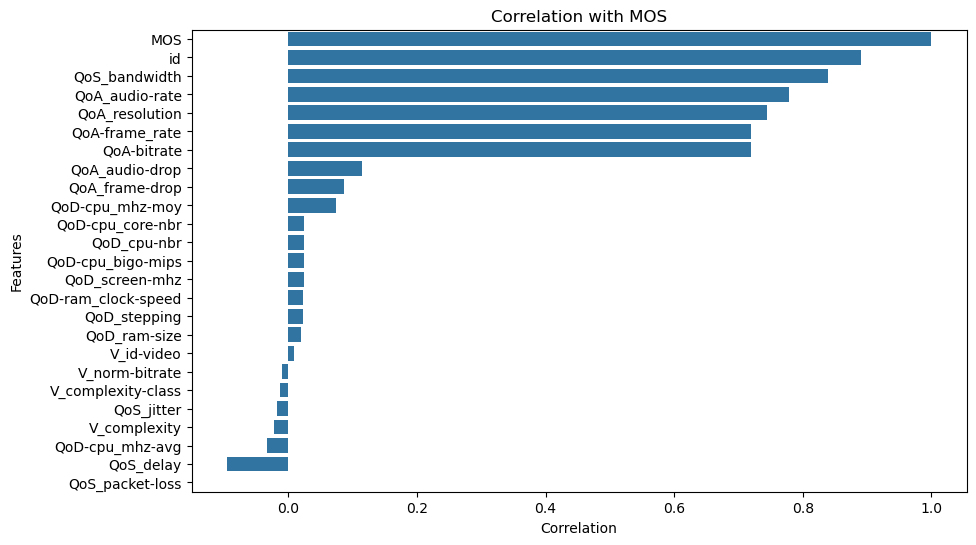

In [5]:
print("\n==============================")
print("STEP 13: Correlation with MOS")
print("==============================")

corr = df.corr(numeric_only=True)

mos_corr = corr["MOS"].sort_values(ascending=False)

print("\nCorrelation with MOS:")
print(mos_corr)

plt.figure(figsize=(10,6))

sns.barplot(x=mos_corr.values, y=mos_corr.index)

plt.title("Correlation with MOS")
plt.xlabel("Correlation")
plt.ylabel("Features")

plt.show()


STEP 15: QoA impact on MOS


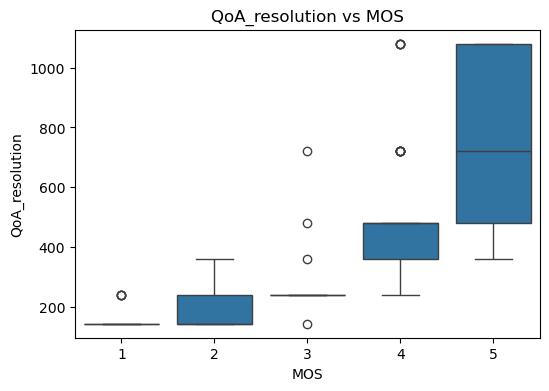

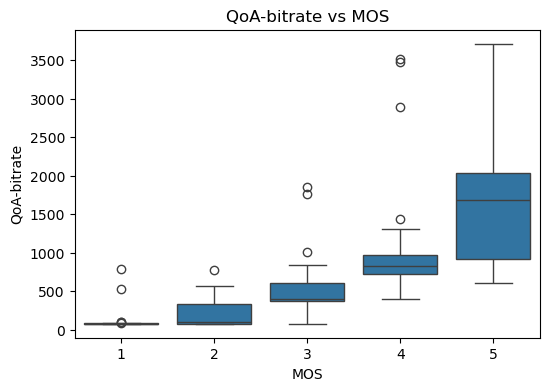

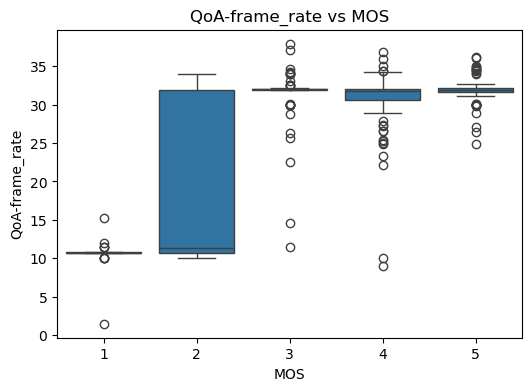

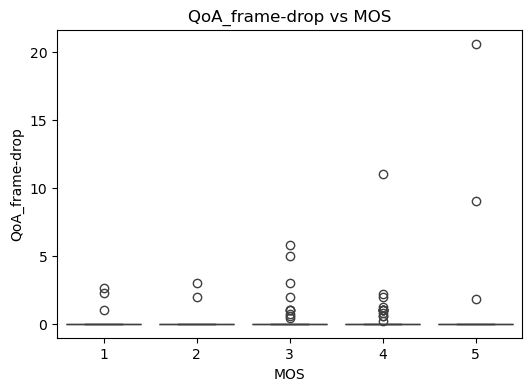

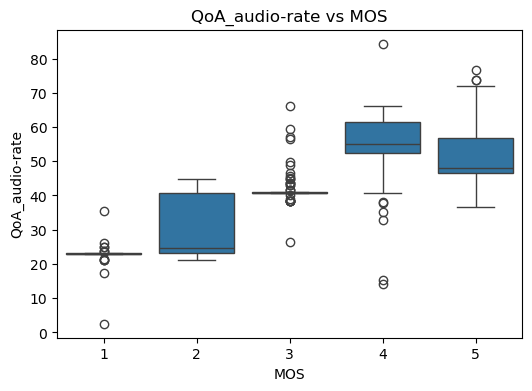

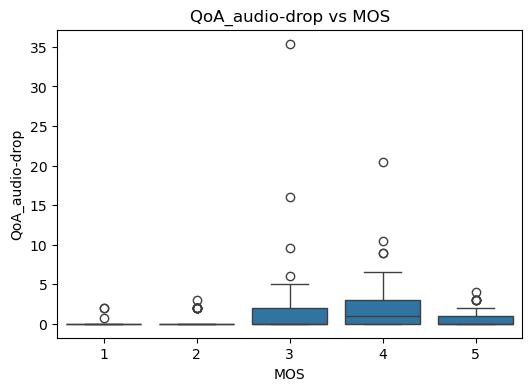

In [6]:
print("\n==============================")
print("STEP 15: QoA impact on MOS")
print("==============================")

for col in qoa_features:
    
    plt.figure(figsize=(6,4))
    
    sns.boxplot(x=df["MOS"], y=df[col])
    
    plt.title(f"{col} vs MOS")
    
    plt.show()

In [7]:
print("\n==============================")
print("STEP 16: Checking feature variability")
print("==============================")

for col in df.columns:
    
    unique_vals = df[col].nunique()
    
    if unique_vals == 1:
        print(f"{col} has only ONE value → {df[col].unique()}")


STEP 16: Checking feature variability
QoS_packet-loss has only ONE value → [0.]



STEP 17: QoS vs MOS analysis

Analyzing QoS_bandwidth
Unique values: 8


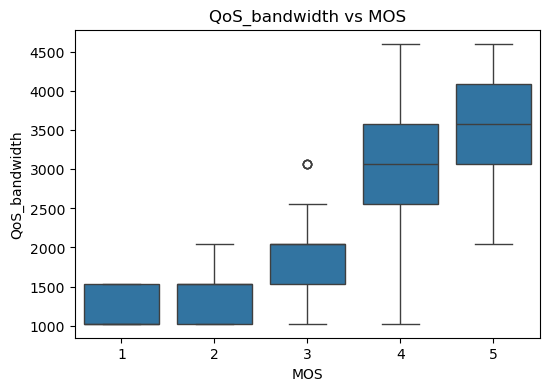


Analyzing QoS_packet-loss
Unique values: 1


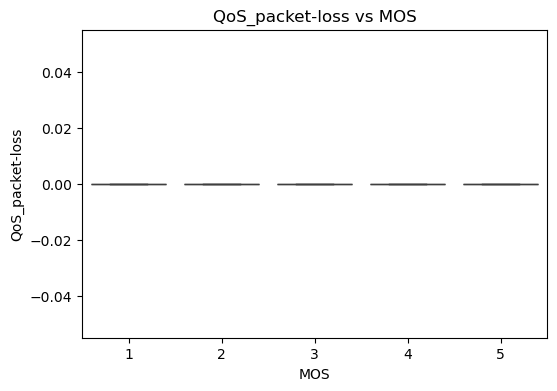


Analyzing QoS_delay
Unique values: 118


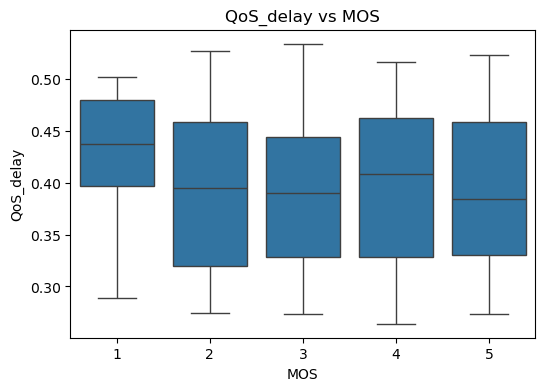


Analyzing QoS_jitter
Unique values: 61


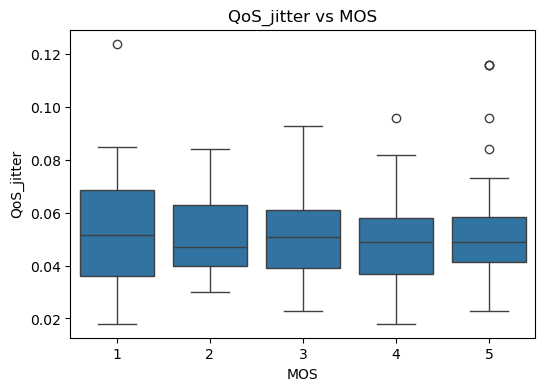

In [8]:
print("\n==============================")
print("STEP 17: QoS vs MOS analysis")
print("==============================")

for feature in qos_features:
    
    print(f"\nAnalyzing {feature}")
    
    print("Unique values:", df[feature].nunique())
    
    plt.figure(figsize=(6,4))
    
    sns.boxplot(x=df["MOS"], y=df[feature])
    
    plt.title(f"{feature} vs MOS")
    
    plt.show()


STEP 18: Video Content vs MOS

Video types present:
V_content
Movie      204
Cartoon     96
Name: count, dtype: int64


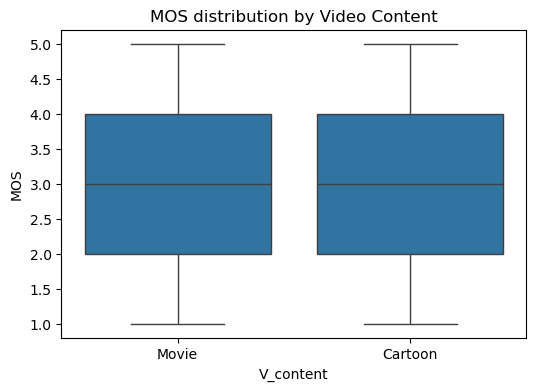

In [9]:
print("\n==============================")
print("STEP 18: Video Content vs MOS")
print("==============================")

print("\nVideo types present:")
print(df["V_content"].value_counts())

plt.figure(figsize=(6,4))

sns.boxplot(x=df["V_content"], y=df["MOS"])

plt.title("MOS distribution by Video Content")

plt.show()


STEP 19: Resolution vs MOS

Available resolutions:
[np.int64(144), np.int64(240), np.int64(360), np.int64(480), np.int64(720), np.int64(1080)]


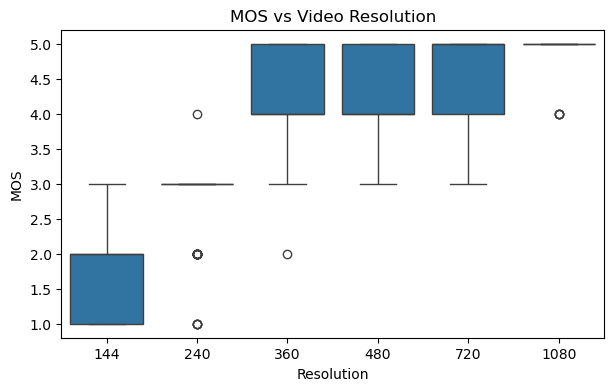

In [10]:
print("\n==============================")
print("STEP 19: Resolution vs MOS")
print("==============================")

print("\nAvailable resolutions:")
print(sorted(df["QoA_resolution"].unique()))

plt.figure(figsize=(7,4))

sns.boxplot(x=df["QoA_resolution"], y=df["MOS"])

plt.title("MOS vs Video Resolution")

plt.xlabel("Resolution")

plt.show()


STEP 20: Correlation Heatmap


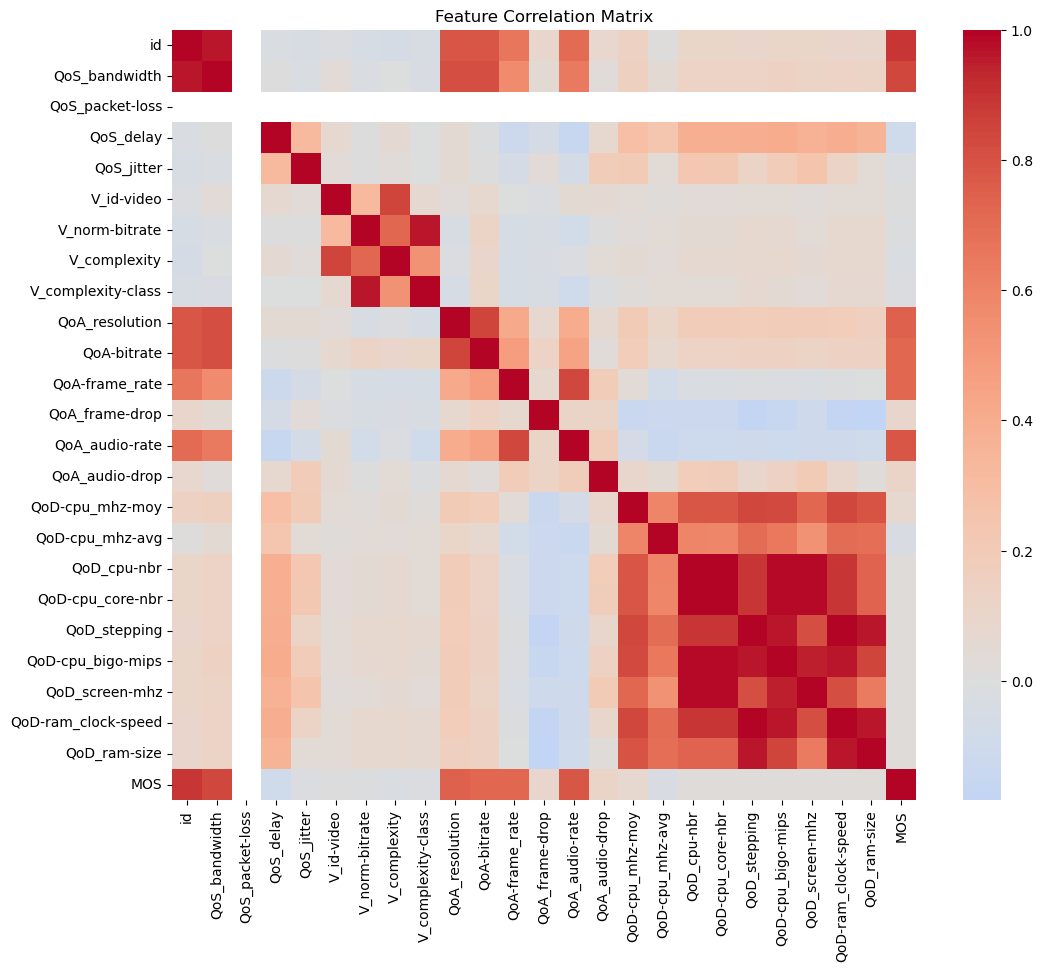

In [11]:
print("\n==============================")
print("STEP 20: Correlation Heatmap")
print("==============================")

plt.figure(figsize=(12,10))

corr = df.corr(numeric_only=True)

sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0
)

plt.title("Feature Correlation Matrix")

plt.show()